# WIP: Germany New Passenger Vehicle Registrations Plots

In Germany, the Kraftfahrtbundesamt (KBA) publishes monthly numbers on passenger vehicle registrations by segment in their FZ 8 publication:

Neuzulassungen von Kraftfahrzeugen und Kraftfahrzeuganhängern  
https://www.kba.de/DE/Statistik/Produktkatalog/produkte/Fahrzeuge/fz8/fz8_gentab.html

I noticed that they provide data by car segment, so I wanted to see EV uptake here plotted.  
The plots should be updated automatically once new data is released if everything works :)

### Related links and dashboards

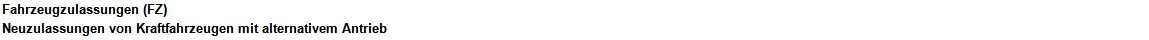

In [1]:
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import de_kba_datagrabber as kba
from utils import PowerType
from plot_utils import draw_pie

In [2]:
kba.ensure_up_to_date()
ev_data = kba.fz8_3_segments_aggregated()

## Comparison of BEV Share over time

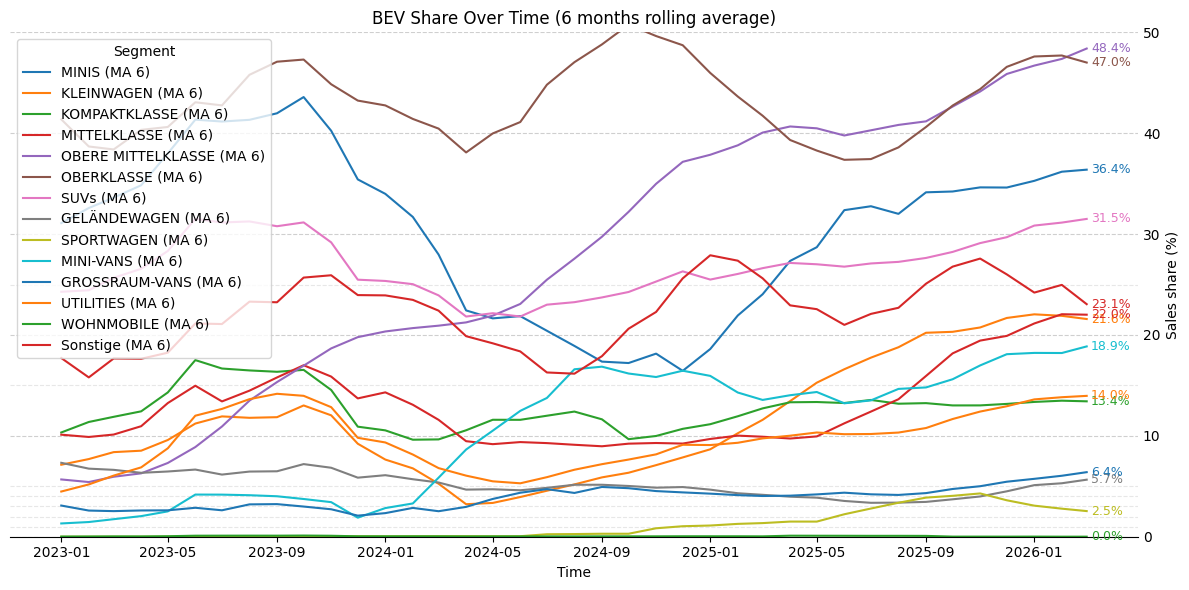

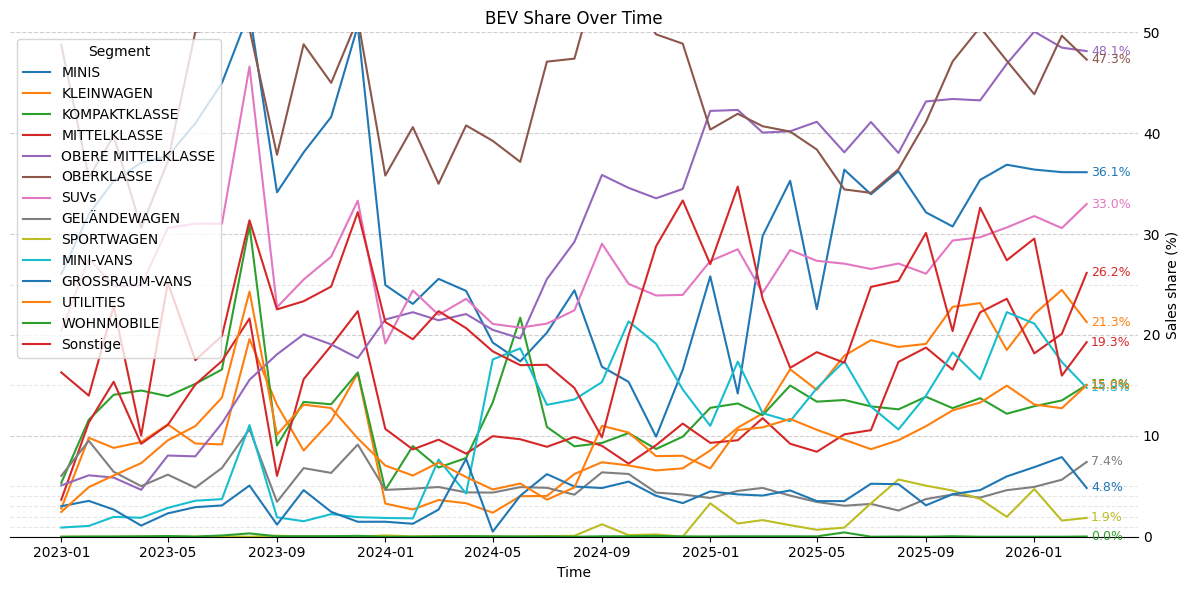

In [3]:
monthy_average_window = 6


def plot_ev_share(only_bev=True, ma_window=1):
    fig, ax = plt.subplots(figsize=(12, 6))
    for t in ev_data.columns.get_level_values(0).unique():
        sub = ev_data.xs(t, axis=1, level=0, drop_level=True).sort_index()
        total = pd.to_numeric(sub.sum(axis=1), errors='coerce').astype('float64')
        bev = sub[PowerType.BEV] if PowerType.BEV in sub.columns else pd.Series(0, index=sub.index, dtype='float64')
        bev = pd.to_numeric(bev, errors='coerce').astype('float64')
        share_pct = bev.div(total.where(total > 0)).fillna(0.0) * 100

        if ma_window <= 1:
            series_to_plot = share_pct
            label = f'{t}'
        else:
            series_to_plot = share_pct.rolling(window=ma_window, min_periods=1, center=True).mean()
            label = f'{t} (MA {ma_window})'

        # Plot line and add last value label
        line, = ax.plot(series_to_plot.index, series_to_plot.values, label=label)
        valid_series = series_to_plot.dropna()
        if not valid_series.empty:
            x_last = valid_series.index[-1]
            y_last = float(valid_series.iloc[-1])
            # Place the label slightly to the right of the last point
            try:
                x_text = x_last + pd.Timedelta(days=5)
            except Exception:
                x_text = x_last
            ax.text(x_text, y_last, f'{y_last:.1f}%', color=line.get_color(), ha='left', va='center', fontsize=9)

    ax.set_ylim(0, 50)

    ax.set_ylabel('Sales share (%)')
    ax.set_xlabel('Time')
    ax.set_title('BEV Share Over Time' if ma_window <= 1 else f'BEV Share Over Time ({ma_window} months rolling average)')
    ax.legend(title='Segment')
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.spines['bottom'].set_visible(False)
    #ax.spines['bottom'].set_visible(False)
    # Add minor ticks for the first couple of percentage points
    ax.yaxis.set_minor_locator(plt.FixedLocator([1, 2, 3, 4, 5, 15, 25]))
    plt.tick_params(axis='y', which='both', length=0)
    plt.grid(axis='y', which='major', linestyle='--', alpha=0.6)
    plt.grid(axis='y', which='minor', linestyle='--', alpha=0.3)

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

    plt.tight_layout()


plot_ev_share(ma_window=monthy_average_window)
#plt.savefig(f'figures/de/heavy_vehicles_bev_share_plot_{monthy_average_window}m_running_average.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'figures/de/heavy_vehicles_bev_share_plot_{monthy_average_window}m_running_average.svg', dpi=300, bbox_inches='tight')
plt.show()

plot_ev_share()
#plt.savefig('figures/de/heavy_vehicles_bev_share_plot.png', dpi=300, bbox_inches='tight')
#plt.savefig('figures/de/heavy_vehicles_bev_share_plot.svg', dpi=300, bbox_inches='tight')
plt.show()


## Share of Power Types for LKW (Rigid Trucks) and Sattelzugmaschinen (Tractor-Trailer)

In [4]:
%%script false --no-raise-error

def plot_by_power_type(kfztype):
    order = ['BEV', 'PHEV', 'Gas', 'Other', 'ICE']
    colors = {
        'BEV': '#2ecc71',  # green
        'PHEV': '#f39c12',  # orange
        'Gas': '#f35c12',  # orange
        'Other': '#c7c7c7', # dark grey
        'ICE': '#9e9e9e' # grey
    }

    df_plot = ev_data.xs(kfztype, axis=1, level=0, drop_level=True).sort_index()

    get_name = lambda c: getattr(c, 'value', str(c))
    names = {c: get_name(c) for c in df_plot.columns}

    other_cols = [c for c, n in names.items() if n not in {'BEV', 'PHEV', 'ICE', 'CNG'}]

    df_plot2 = pd.DataFrame({
        'BEV': df_plot[PowerType.BEV],
        'PHEV': df_plot[PowerType.PHEV],
        'Gas': df_plot[PowerType.CNG],
        'Other': df_plot[other_cols].sum(axis=1) if other_cols else 0,
        'ICE': df_plot[PowerType.ICE],
    }).reindex(columns=order)

    df_share2 = df_plot2.div(df_plot2.sum(axis=1), axis=0)

    color_list = [colors[k] for k in order]

    fig2, axes2 = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    df_plot2.plot(kind='area', stacked=True, ax=axes2[0], color=color_list)
    axes2[0].set_title(f'{kfztype} by Powertype over Time (Absolute)')
    axes2[0].set_ylabel('Value')
    axes2[0].yaxis.set_label_position("right")
    axes2[0].yaxis.tick_right()

    df_share2.plot(kind='area', stacked=True, ax=axes2[1], color=color_list)
    axes2[1].set_title(f'{kfztype} by Powertype over Time (Fraction)')
    axes2[1].set_xlabel('Time')
    axes2[1].set_ylabel('Share (0–1)')
    axes2[1].set_ylim(0, 1)
    axes2[1].yaxis.set_label_position("right")
    axes2[1].yaxis.tick_right()

    plt.tight_layout()

plot_by_power_type('Lastkraftwagen')
#plt.savefig(f'figures/de/lastkraftwagen_by_fueltype_plot.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'figures/de/lastkraftwagen_by_fueltype_plot.svg', dpi=300, bbox_inches='tight')
plt.show()

plot_by_power_type('Sattelzugmaschinen')
#plt.savefig(f'figures/de/sattelzugmaschinen_by_fueltype_plot.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'figures/de/sattelzugmaschinen_by_fueltype_plot.svg', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
%%script false --no-raise-error
n_months = 6
vehicle_types = ['Kraftomnibusse', 'Lastkraftwagen', 'Sattelzugmaschinen']

# Default display order and colors (can contain all fuel types; "Other" will be added/updated dynamically)
order = ['BEV', 'PHEV', 'FCEV', 'HY', 'HEV', 'Gas', 'Other', 'ICE']
colors = {
    'BEV': '#2ecc71',
    'PHEV': '#f39c12',
    'FCEV': '#3498db',
    'HY': '#54a8fb',
    'HEV': '#e74c3c',
    'Gas': '#f35c12',
    'Other': '#c7c7c7',
    'ICE': '#9e9e9e'
}
fuel_names = {
#    'FCEV': 'Fuel-Cell',
#    'HY': 'Hydrogen',
    'HEV': 'Hybrid',
#    'Gas': 'Gas (LPG / CNG)',
}


def plot_fuel_share_pie(ax, vtype, n_months=3, others_threshold=0.005, order=order, colors=colors):
    sub = ev_data.xs(vtype, axis=1, level=0, drop_level=True).sort_index()

    # Map Enum columns to string names once
    get_name = lambda c: getattr(c, 'value', str(c))
    name_map = {c: get_name(c) for c in sub.columns}
    df_named = sub.rename(columns=name_map)

    # Aggregate in case multiple columns map to the same name
    df_named = df_named.T.groupby(level=0).sum().T

    # Ensure numeric float dtype
    df_named = df_named.apply(pd.to_numeric, errors='coerce').astype('float64')

    # Compute monthly shares, then average over the last n months
    df_share = df_named.div(df_named.sum(axis=1), axis=0).fillna(0.0)
    if isinstance(df_share.index, pd.DatetimeIndex):
        recent = df_share.last(f'{n_months}M')
    else:
        recent = df_share.tail(n_months)

    avg_share = recent.mean(axis=0).fillna(0.0)

    # Dynamically group categories below threshold into "Other"
    small_cats = [k for k, v in avg_share.items() if k != 'Other' and v < others_threshold]
    if small_cats:
        other_value = avg_share.get('Other', 0.0) + float(avg_share[small_cats].sum())
        avg_share = avg_share.drop(index=small_cats)
        if other_value > 0:
            avg_share['Other'] = other_value

    # If no data or all zeros, hide this plot
    if avg_share.sum() <= 0:
        ax.axis('off')
        ax.set_title(f'{vtype}: No data')
        return

    # Reorder according to desired order, then append any remaining categories
    ordered_keys = [k for k in order if k in avg_share.index] + [k for k in avg_share.index if k not in order]
    avg_share = avg_share[ordered_keys]
    
    for k,v in fuel_names.items():
        if k in colors:
            colors[v] = colors[k]

    draw_pie(
        ax=ax,
        values=avg_share.values,
        labels=list(map(lambda n: fuel_names.get(n, n), avg_share.index)),
        colors_map=colors,
        autopct_threshold=0.02,
        startangle=90,
        counterclock=False,
        pctdistance=0.72,
        radius=0.95,
        label_line_radius=0.98,
        label_radius=1.05,
        label_vertical_aligned=False,
        text_fontsize=9,
        show=False
    )

    start_m = recent.index.min().strftime('%B')
    end_m = recent.index.max().strftime('%B')
    months_label = start_m if start_m == end_m else f'{start_m} - {end_m}'

    ax.set_title(f'{vtype} ({months_label})')
    ax.margins(0.15, 0.15)
    ax.axis('scaled')


# Plot all vehicle types in one figure for last month
fig, axes = plt.subplots(1, len(vehicle_types), figsize=(4 * len(vehicle_types) + 2, 6))
if len(vehicle_types) == 1:
    axes = [axes]

for ax, vt in zip(axes, vehicle_types):
    plot_fuel_share_pie(ax, vt, n_months=1)

plt.tight_layout()
#plt.savefig('figures/de/heavy_vehicles_by_fueltype_latest_month.png', dpi=300, bbox_inches='tight')
#plt.savefig('figures/de/heavy_vehicles_by_fueltype_latest_month.svg', dpi=300, bbox_inches='tight')
plt.show()

# Plot all vehicle types for the last n months
fig, axes = plt.subplots(1, len(vehicle_types), figsize=(4 * len(vehicle_types) + 2, 6))
if len(vehicle_types) == 1:
    axes = [axes]

for ax, vt in zip(axes, vehicle_types):
    plot_fuel_share_pie(ax, vt, n_months=n_months)

plt.tight_layout()
#plt.savefig(f'figures/de/heavy_vehicles_by_fueltype_last_{n_months}_months.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'figures/de/heavy_vehicles_by_fueltype_last_{n_months}_months.svg', dpi=300, bbox_inches='tight')
plt.show()


### Other Stuff

In [6]:
%%script false --no-raise-error
#kfztype = 'Lastkraftwagen'
kfztype = 'Sattelzugmaschinen'

df_plot = ev_data.xs(kfztype, axis=1, level=0, drop_level=True).sort_index()
df_share = df_plot.div(df_plot.sum(axis=1), axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

df_plot.plot(kind='area', stacked=True, ax=axes[0])
axes[0].set_title(f'{kfztype} by Powertype over Time (Absolute)')
axes[0].set_ylabel('Value')

df_share.plot(kind='area', stacked=True, ax=axes[1])
axes[1].set_title(f'{kfztype} by Powertype over Time (Fraction)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Share (0–1)')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
